# **Predicting Diabetes Status Using Machine Learning and Population Health Indicators**

## **Introduction**: Diabetes is a common public health problem that affects millions of people worldwide. Early identification of people at risk can help support prevention and timely management. This project uses machine learning to predict diabetes status based on population health indicators such as BMI, age, high blood pressure, cholesterol, physical activity, and other health and lifestyle factors. The goal is to develop and evaluate a classification model that can identify patterns associated with diabetes.

## **1. Data Preprocessing and Exploration**

### **Load and explore the dataset**

In [3]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [4]:
# Load the dataset

diabetes_data = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

In [ ]:
# Display the first 5 rows

print(diabetes_data.head())


   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

In [7]:
# Understand the sturcture and dimensions 

print(diabetes_data.info())


<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

### **Clean the dataset: Handle missing values and outliers** 

In [8]:
# Identify and handle missing values

diabetes_data.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
# Check for duplicates

diabetes_data.duplicated().sum()

np.int64(23899)

In [ ]:
# Display the duplicates by column

duplicates = diabetes_data[diabetes_data.duplicated(keep=False)]

duplicates.sort_values(
    by=list(diabetes_data.columns)).head(20)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0


In [14]:
duplicate_count = diabetes_data.duplicated().sum()

duplicate_percentage = (
    duplicate_count / len(diabetes_data)
) * 100

print("Duplicate rows:", duplicate_count)
print("Percentage:", round(duplicate_percentage, 2), "%")

Duplicate rows: 23899
Percentage: 9.42 %


#### **Comments on duplicates handling**: The dataset contained 23,899 duplicated rows, representing approximately 9.42% of the observations. Because the dataset consists of population health survey indicators and does not contain a unique respondent identifier, identical records may represent different individuals with the same health and demographic characteristics. Therefore, duplicate records were investigated before deciding whether to remove them.

In [ ]:
# Summary statistics

diabetes_data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


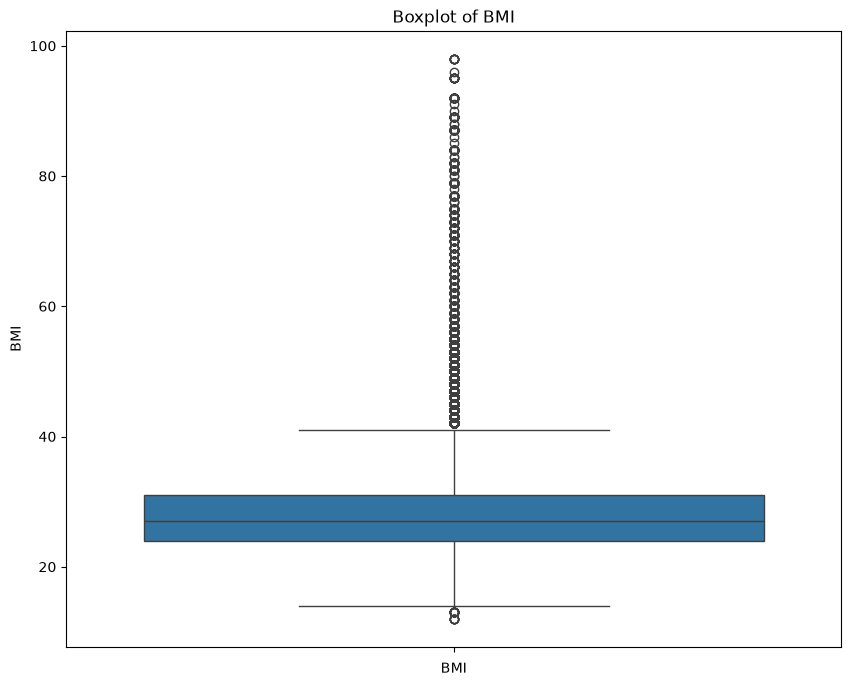

In [17]:
# Visualize BMI with a boxplot

plt.figure(figsize=(10,8))

sns.boxplot(y=diabetes_data["BMI"])
plt.title("Boxplot of BMI")
plt.xlabel("BMI")
plt.show()

In [ ]:
# print the lower and upper bound

Q1 = diabetes_data["BMI"].quantile(0.25)
Q3 = diabetes_data["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 24.0
Q3: 31.0
IQR: 7.0
Lower bound: 13.5
Upper bound: 41.5


In [21]:


bmi_outliers = diabetes_data[
    (diabetes_data["BMI"] < lower_bound) |
    (diabetes_data["BMI"] > upper_bound)]

print("Number of BMI outliers:", len(bmi_outliers))
print(
    "Percentage of BMI outliers:",
    round(len(bmi_outliers) / len(diabetes_data) * 100, 2),
    "%"
)

Number of BMI outliers: 9847
Percentage of BMI outliers: 3.88 %


**Outlier Assessment**: BMI was assessed for outliers using the interquartile range (IQR) method. A total of 9,847 observations (3.88%) were identified as potential outliers. These observations were retained because extreme BMI values may represent valid population health observations and may provide important information for predicting diabetes status.

### **Converting the outcome variable into binary**

In [ ]:
# Display the diabetes categories

diabetes_data["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [30]:
# Keep only no diabetes (0) and diabetes (2)
diabetes_binary = diabetes_data[
    diabetes_data["Diabetes_012"] != 1
].copy()

In [ ]:
# Recode diabetes from 2 to 1

diabetes_binary["Diabetes_binary"] = (
    diabetes_binary["Diabetes_012"].replace({0: 0, 2: 1})
)

# Remove the original outcome variable
diabetes_binary.drop("Diabetes_012", axis=1, inplace=True)

In [ ]:
# Verify

diabetes_binary["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    213703
1.0     35346
Name: count, dtype: int64

In [34]:
# Percentage of each class

diabetes_binary["Diabetes_binary"].value_counts(normalize=True) * 100

Diabetes_binary
0.0    85.807612
1.0    14.192388
Name: proportion, dtype: float64

### **Visualize relationships in the data**

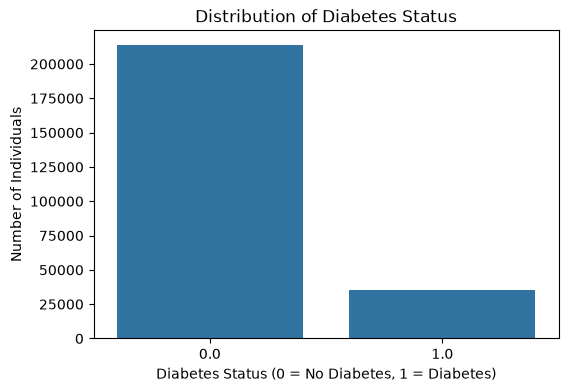

In [ ]:
# Diabetes class distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=diabetes_binary,
    x="Diabetes_binary")

plt.title("Distribution of Diabetes Status")
plt.xlabel("Diabetes Status (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Individuals")
plt.show()

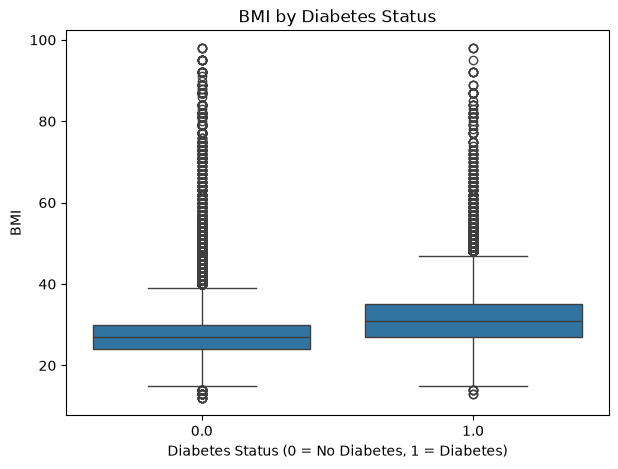

In [37]:
# BMI by diabetes status

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=diabetes_binary,
    x="Diabetes_binary",
    y="BMI"
)

plt.title("BMI by Diabetes Status")
plt.xlabel("Diabetes Status (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")
plt.show()

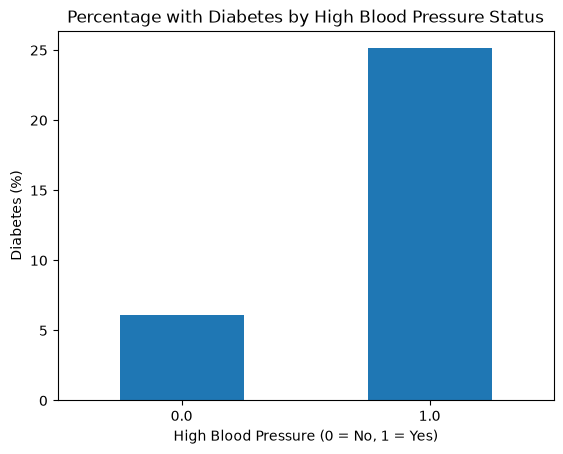

In [38]:
# High blood pressure and diabetes

bp_diabetes = (
    diabetes_binary
    .groupby("HighBP")["Diabetes_binary"]
    .mean() * 100
)

bp_diabetes.plot(kind="bar")

plt.title("Percentage with Diabetes by High Blood Pressure Status")
plt.xlabel("High Blood Pressure (0 = No, 1 = Yes)")
plt.ylabel("Diabetes (%)")
plt.xticks(rotation=0)
plt.show()

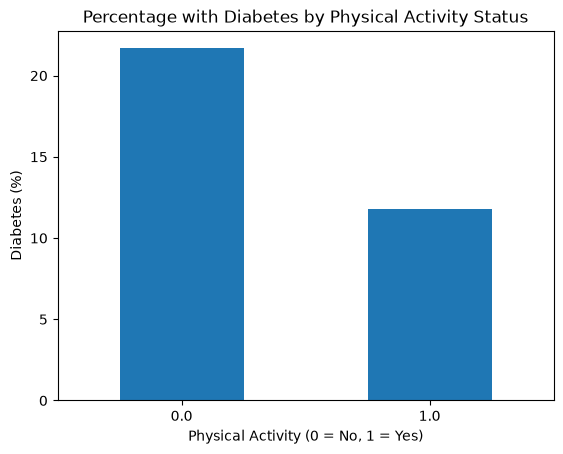

In [39]:
# Physical activity and diabetes

activity_diabetes = (
    diabetes_binary
    .groupby("PhysActivity")["Diabetes_binary"]
    .mean() * 100
)

activity_diabetes.plot(kind="bar")

plt.title("Percentage with Diabetes by Physical Activity Status")
plt.xlabel("Physical Activity (0 = No, 1 = Yes)")
plt.ylabel("Diabetes (%)")
plt.xticks(rotation=0)
plt.show()